In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from skorch import NeuralNetClassifier
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata
from astroML.utils import completeness_contamination

In [23]:
oil_prices = pd.read_csv('proj2_data/oil_prices_daily.csv')
iran_exp = pd.read_csv('proj2_data/iran_oil_exports.csv')
geopol_events = pd.read_csv('proj2_data/geopolitical_events.csv')
risk_indicators = pd.read_csv('proj2_data/risk_indicators.csv')
sanctions = pd.read_csv('proj2_data/sanctions_timeline.csv')
dati = pd.read_csv('proj2_data/petrolio_hor.csv')

In [24]:

dati['geopol_event_type_filled'] = dati['geopol_event_type'].fillna('none')
dati['geopol_region_filled'] = dati['geopol_region'].fillna('none')
dati['geopol_shock_direction_filled'] = dati['geopol_shock_direction'].fillna('none')
dati['geopol_severity_filled'] = dati['geopol_severity'].fillna('none')
dati['sanctions_imposing_authority_filled'] = dati['sanctions_imposing_authority'].fillna('none')

event_type_map = {'none': 0, 'diplomatic': 1, 'terror': 2, 'political': 3, 'sanctions':4, 'market':5, 'economic':6, 'military': 7}
dati['event_type_encoded'] = dati['geopol_event_type_filled'].map(event_type_map)

region_map = {'none': 0, 'Middle East': 1, 'Global': 2}
dati['region_encoded'] = dati['geopol_region_filled'].map(region_map)

shock_dir_map = {'none': 0, 'up': 1, 'down': 2}
dati['shock_dir_encoded'] = dati['geopol_shock_direction_filled'].map(shock_dir_map)

severity_map = {'none': 0, 'low': 1, 'medium': 2, 'high': 3, 'extreme': 4}
dati['severity_encoded'] = dati['geopol_severity_filled'].map(severity_map)

imposing_authority_map = {'none': 0, 'US': 1, 'EU': 2, 'UN': 3, 'US/EU': 4, 'US/EU/UN': 5}
dati['imposing_authority_encoded'] = dati['sanctions_imposing_authority_filled'].map(imposing_authority_map)

#sanc_category_map = {'asset_freeze': 1, 'trade_ban': 2, 'secondary_sanctions': 3, 'nuclear_sanctions': 4, 'comprehensive': 5, 'financial': 6, 'oil_embargo': 7, 'oil_sanctions': 8, 'partial_relief': 9 }

features = ['opec_production_mbd', 'us_rig_count', 'geopolitical_risk_index', 'iran_specific_risk_bp', 'vix_index', 
            'usd_index_dxy', 'gold_usd_oz', 'opec_spare_capacity_mbd', 'brent_risk_premium_usd', 'energy_security_index',
            'geopol_has_event', 'event_type_encoded', 'region_encoded', 'geopol_iran_involved', 'geopol_price_shock_pct', 'shock_dir_encoded',
            'geopol_duration_days', 'severity_encoded', 'geopol_strait_of_hormuz_risk', 'geopol_sanctions_related', 'geopol_military_action',
            'sanctions_has_event', 'imposing_authority_encoded', 'sanctions_gdp_impact_pct', 'sanctions_oil_sector_affected',
            'sanctions_financial_sector_affected', 'sanctions_is_relief', 'sanctions_cumulative_pressure'  
            ]

dati[features] = dati[features].fillna(0)

X_full = np.transpose(np.vstack([dati[feat] for feat in features]))
X = X_full[365:, :]
X_2026 = X_full[:365, :]

threshold_brent = 100.0 #threshold on the price [usd]
labels_full = [int(dati['brent_usd'][i] >= threshold_brent) for i in range(len(dati['brent_usd']))]
labels = labels_full[365:]
labels_2026 = labels_full[:365]


## Training

In [25]:
#defining the structure for the NN
class MLP(nn.Module):
    def __init__(self, nhidden1, nhidden2, nhidden3, dp_rate):
        super(MLP, self).__init__()
        self.fc_1 = nn.Linear(15, nhidden1)
        self.drop1 = nn.Dropout(dp_rate)
        self.fc_2 = nn.Linear(nhidden1, nhidden2)
        self.drop2 = nn.Dropout(dp_rate)
        self.fc_3 = nn.Linear(nhidden2, nhidden3)
        self.drop3 = nn.Dropout(dp_rate)
        self.fc_o = nn.Linear(nhidden3, 1)
    

    def forward(self, x):
        x = F.relu(self.fc_1(x))
        x = self.drop1(x)
        x = F.relu(self.fc_2(x))
        x = self.drop2(x)
        x = F.relu(self.fc_3(x))
        x = self.drop3(x)

        x = self.fc_o(x)
        return x

In [26]:
sk_net = NeuralNetClassifier(
    MLP,
    max_epochs=30,
    optimizer=torch.optim.Adam,
    optimizer__weight_decay = 1e-4,
    criterion=nn.BCEWithLogitsLoss,
    train_split=None
)

# hyperparameter grid considered during CV
param_dist = {
    'lr': [5e-3, 1e-2, 5e-2],
    'module__nhidden1': [64, 128, 256],
    'module__nhidden2': [64, 128, 256],
    'module__nhidden3': [32, 64, 128],
    'module__dp_rate': [0.1, 0.15, 0.2],
    'batch_size': [128, 256]
}
k = 5 # number of folds

# cross validation
CV = RandomizedSearchCV(sk_net, param_distributions=param_dist,
                        scoring='accuracy', cv=k, n_iter=50)
X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)

SC = StandardScaler()
pca = PCA(n_components=15)
scaled_X_train = SC.fit_transform(X_train)
reduced_X_train = pca.fit_transform(scaled_X_train)
CV.fit(np.array(reduced_X_train, dtype=np.float32), np.array(y_train, dtype=np.float32)[:, None])

CV.best_params_



  epoch    train_loss     dur
-------  ------------  ------
      1        0.2573  0.9549
      2        0.1397  0.9608
      3        0.1051  0.9467
      4        0.0938  0.7907
      5        0.0957  0.7661
      6        0.0867  0.7781
      7        0.0830  0.8682
      8        0.0748  0.8973
      9        0.0727  0.9021
     10        0.0875  1.0145
     11        0.1099  0.8649
     12        0.2791  0.8365
     13        0.1815  0.7058
     14        0.2096  0.6245
     15        0.1548  0.5763
     16        0.1520  0.5947
     17        0.1405  0.6026
     18        0.1274  0.6204
     19        0.1205  0.6202
     20        0.1112  0.5928
     21        0.1155  0.5884
     22        0.1113  0.6440
     23        0.1058  0.6178
     24        0.1068  0.5653
     25        0.0993  0.6531
     26        0.1050  0.6975
     27        0.1171  0.6271
     28        0.2020  0.5213
     29        0.1621  0.4321
     30        0.1170  0.4681
  epoch    train_loss     dur
-------  -

{'module__nhidden3': 128,
 'module__nhidden2': 64,
 'module__nhidden1': 128,
 'module__dp_rate': 0.2,
 'lr': 0.005,
 'batch_size': 128}

In [27]:
# network hyperparameters
nh1 = CV.best_params_['module__nhidden1']
nh2 = CV.best_params_['module__nhidden2']
nh3 = CV.best_params_['module__nhidden3']
lr = CV.best_params_['lr']
dr = CV.best_params_['module__dp_rate']
batch_size = CV.best_params_['batch_size']

In [28]:
#for statistical comaprison of the models
accuracy_int = []
accuracy_2026 = []
proba_2026 = []
proba_int = []

# for plotting accuracy and loss function on a given run
accuracy_vect = []
test_loss_vect = []
ep = []

for run in range(10):

    X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)

    SC = StandardScaler()
    scaled_X_train = SC.fit_transform(X_train)
    scaled_X_test = SC.transform(X_test)
    pca = PCA(n_components=15)
    reduced_X_train = pca.fit_transform(scaled_X_train)
    reduced_X_test = pca.transform(scaled_X_test)

    #loading the data into pytorch tensors
    X_train_torch = torch.tensor(reduced_X_train, dtype=torch.float32)
    y_train_torch = torch.tensor(y_train, dtype=torch.float32)

    X_test_torch = torch.tensor(reduced_X_test, dtype=torch.float32)
    y_test_torch = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = torchdata.TensorDataset(X_train_torch, y_train_torch.view(-1, 1))
    test_dataset = torchdata.TensorDataset(X_test_torch, y_test_torch.view(-1, 1))

    train_dataloader = torchdata.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = MLP(nh1, nh2, nh3, dr) # network

    criterion = torch.nn.BCEWithLogitsLoss() # loss function (BCE with logits)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4) # parameter optimization (Adam with L2 loss)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                                        patience=3,
                                                        threshold=1e-3) # scheduler to adaptively optimize for the learning rate

    epochs = 100 # number of epochs
    no_impr_epochs = 0
    min_valid_loss = float('inf')
    patience = 5

    #training
    for t in range(epochs):

        train_loss = 0.
        for X_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.view(-1, 1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        with torch.no_grad():
            pred_logits = model(X_test_torch)
            valid_loss = criterion(pred_logits, y_test_torch.view(-1, 1))
            y_pred = (torch.sigmoid(pred_logits) > 0.5).float() # applying sigmoid activation fucntion on the output of the final layer

            if valid_loss > min_valid_loss*(1-1e-3):
                    no_impr_epochs += 1
            else:
                min_valid_loss = valid_loss
                no_impr_epochs = 0
            if (no_impr_epochs == patience or t == epochs-1): # stopping training after 5 epochs without improvement
                accuracy = (y_pred.eq(y_test_torch.view(-1,1)).sum().item()) / len(y_test_torch)
                class_proba_int = []
                for p in pred_logits:
                    if (p >= 0.5):
                        class_proba_int.append(torch.sigmoid(p))
                    else:
                        class_proba_int.append(1-torch.sigmoid(p))
                av_proba_int = np.mean(class_proba_int)
                std_proba_int = np.std(class_proba_int)
                proba_int.append(av_proba_int)

                comp, cont = completeness_contamination(y_pred.numpy().ravel(), y_test_torch.numpy().ravel())
                print('Epoch: '+str(t+1))
                print('Training loss: '+f"{train_loss:.3f}"+' Test loss: '+f"{valid_loss.item():.3f}")
                print('Accuracy: '+f"{accuracy:.3f}"+' Completeness: '+f"{comp:.3f}"+' Contamination: '+f"{cont:.3f}")
                accuracy_int.append(accuracy)
                print('FINISHED TRAINING')
                break
        
        if ((t+1)%3 == 0): # evaluating performance every 3 epochs
            accuracy = (y_pred.eq(y_test_torch.view(-1,1)).sum().item()) / len(y_test_torch)
            
            if (run == 7):
                accuracy_vect.append(accuracy)
                test_loss_vect.append(valid_loss)
                ep.append(t)

            comp, cont = completeness_contamination(y_pred.numpy().ravel(), y_test_torch.numpy().ravel())
            print('Epoch: '+str(t+1))
            print('Training loss: '+f"{train_loss:.3f}"+' Test loss: '+f"{valid_loss.item():.3f}")
            print('Accuracy: '+f"{accuracy:.3f}"+' Completeness: '+f"{comp:.3f}"+' Contamination: '+f"{cont:.3f}")
            print('---------------------------------------------------------------')
        scheduler.step(valid_loss.item())

    scaled_X_2026 = SC.transform(X_2026)
    reduced_X_2026 = pca.transform(scaled_X_2026)
    X_2026_torch = torch.tensor(reduced_X_2026, dtype=torch.float32)
    y_2026_torch = torch.tensor(labels_2026, dtype=torch.float32)

    pred_logits_2026 = model(X_2026_torch)
    y_pred_2026 = (torch.sigmoid(pred_logits_2026) > 0.5).float()
    with torch.no_grad():
        class_proba_2026 = 0.
        for p in pred_logits_2026:
            if (p >= 0.5):
                class_proba_2026 = class_proba_2026 + torch.sigmoid(p)
            else:
                class_proba_2026 = class_proba_2026 + (1-torch.sigmoid(p))
        av_proba_2026 = class_proba_2026/len(pred_logits_2026)
        #std_proba_2026 = np.std(class_proba_2026)
        proba_2026.append(av_proba_2026)
            
        accuracy_2026.append((y_pred_2026.eq(y_2026_torch.view(-1,1)).sum().item()) / len(y_2026_torch))


print('------------------------------------------------------------------')
print('Accuracy on internal testing: '+str(np.mean(accuracy_int))+' +- '+str(np.std(accuracy_int)))
print('Average probabilitity in classification (internal): '+str(np.mean(proba_int))+' +- '+str(np.std(proba_int)))
print('Accuracy on 2026 data: '+str(np.mean(accuracy_2026))+' +- '+str(np.std(accuracy_2026)))
print('Average probabilitity in classification (2026): '+str(np.mean(proba_2026))+' +- '+str(np.std(proba_2026)))
    



Epoch: 3
Training loss: 4.426 Test loss: 0.080
Accuracy: 0.979 Completeness: 0.971 Contamination: 0.120
---------------------------------------------------------------
Epoch: 6
Training loss: 3.013 Test loss: 0.041
Accuracy: 0.987 Completeness: 0.980 Contamination: 0.074
---------------------------------------------------------------
Epoch: 9
Training loss: 2.759 Test loss: 0.037
Accuracy: 0.986 Completeness: 0.951 Contamination: 0.063
---------------------------------------------------------------
Epoch: 12
Training loss: 2.344 Test loss: 0.046
Accuracy: 0.981 Completeness: 0.892 Contamination: 0.047
---------------------------------------------------------------
Epoch: 15
Training loss: 1.983 Test loss: 0.051
Accuracy: 0.982 Completeness: 0.941 Contamination: 0.077
---------------------------------------------------------------
Epoch: 16
Training loss: 1.799 Test loss: 0.040
Accuracy: 0.986 Completeness: 0.961 Contamination: 0.071
FINISHED TRAINING
Epoch: 3
Training loss: 3.357 Test 

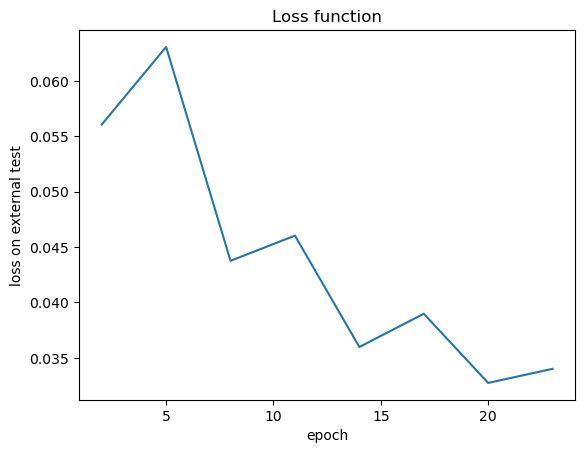

In [29]:
plt.plot(ep, test_loss_vect)
plt.xlabel('epoch')
plt.ylabel('loss on external test')
plt.title('Loss function')
plt.show()

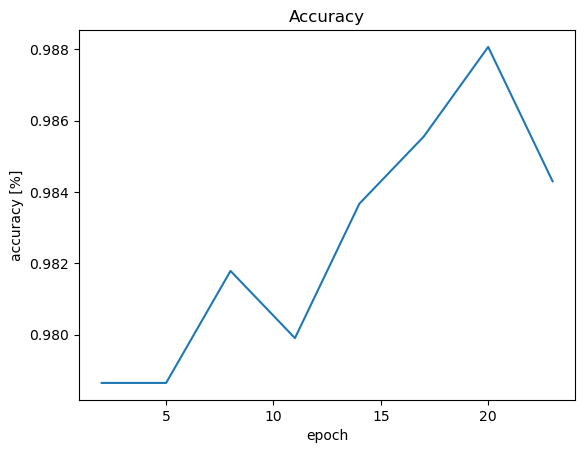

In [30]:
plt.plot(ep, accuracy_vect)
plt.xlabel('epoch')
plt.ylabel('accuracy [%]')
plt.title('Accuracy')
plt.show()

## SKlearn Network

In [19]:
sklearn_NN = MLPClassifier(hidden_layer_sizes=(128, 128, 64), activation='relu', solver='adam', alpha=0.0001, batch_size='auto', learning_rate_init=0.005)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)
SC_n = StandardScaler()
scaled_X_train = SC_n.fit_transform(X_train)
sklearn_NN.fit(scaled_X_train, y_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.005
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,None


In [21]:
scaled_X_test = SC.transform(X_test)
predict_y_NN = sklearn_NN.predict(scaled_X_test)

In [97]:
print(accuracy_score(y_test, predict_y_NN))

0.9902200488997555
